## Generalized Random Forests

GRF の公式ページの Usage Examples  

https://grf-labs.github.io/grf/

を以下で実行しています。
GRF は R の package なので、Google Colab では右上のボタン（runtime の変更）で R に切り替えてから、実行してください。
また何かあれば、お知らせください。

In [1]:
install.packages("grf")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘zoo’, ‘DiceKriging’, ‘lmtest’, ‘sandwich’, ‘RcppEigen’




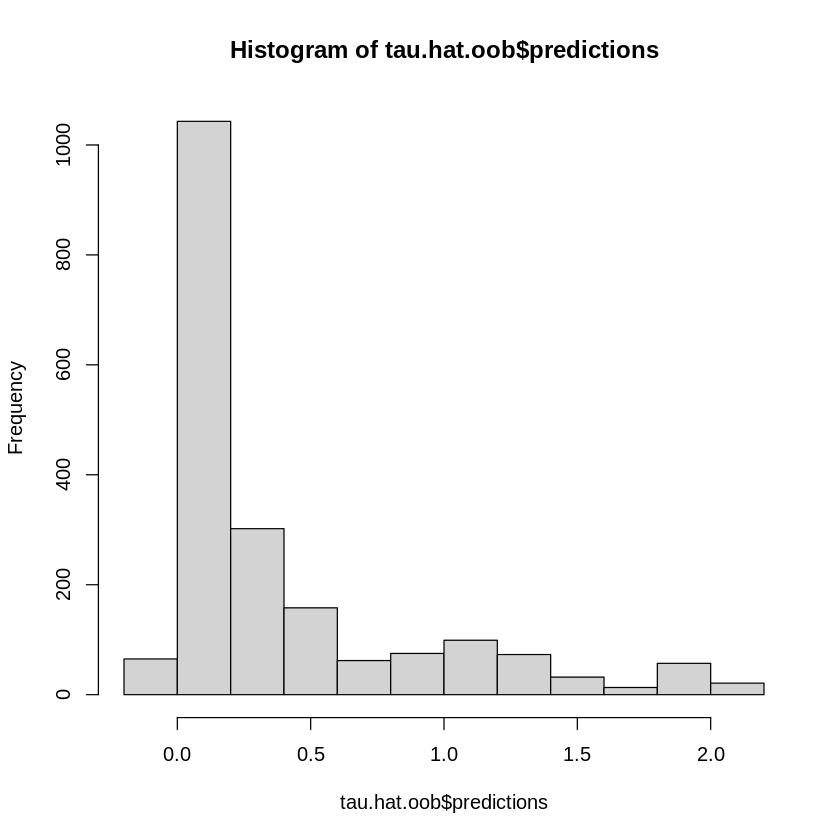

estimate    std.err 
0.40500473 0.04855177

estimate    std.err 
0.46795973 0.04987815

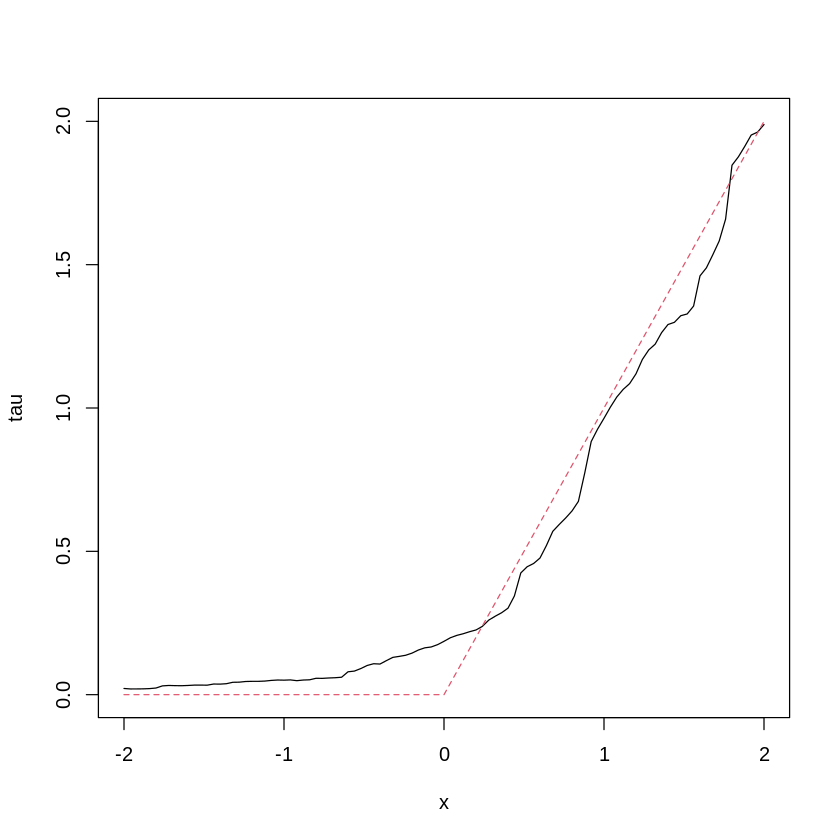

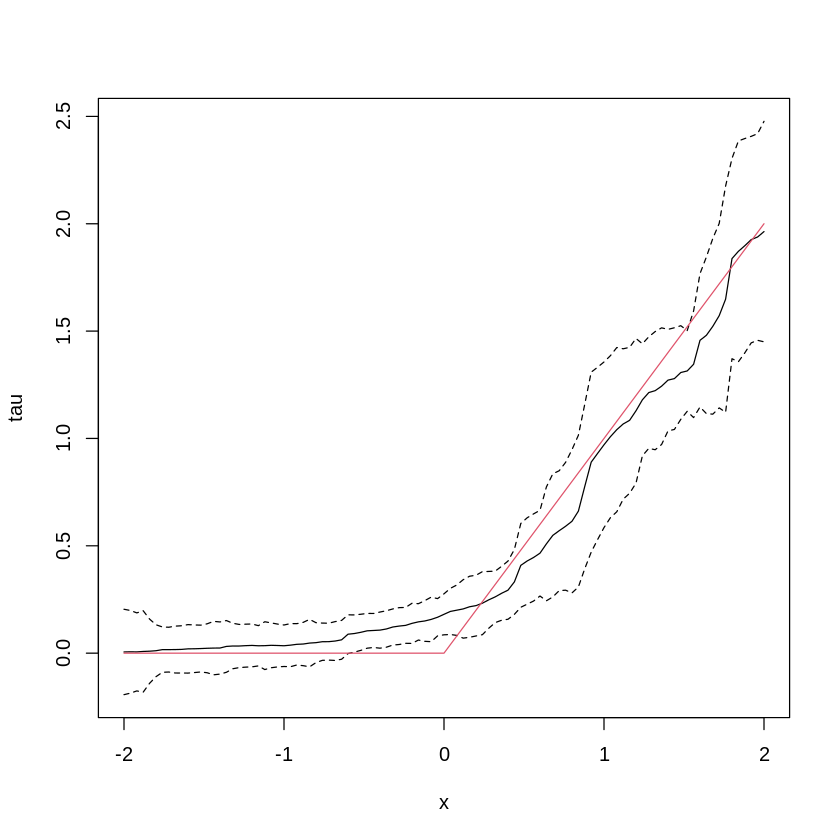

[1] "AUTOC: 0.09 +/ 0.1"

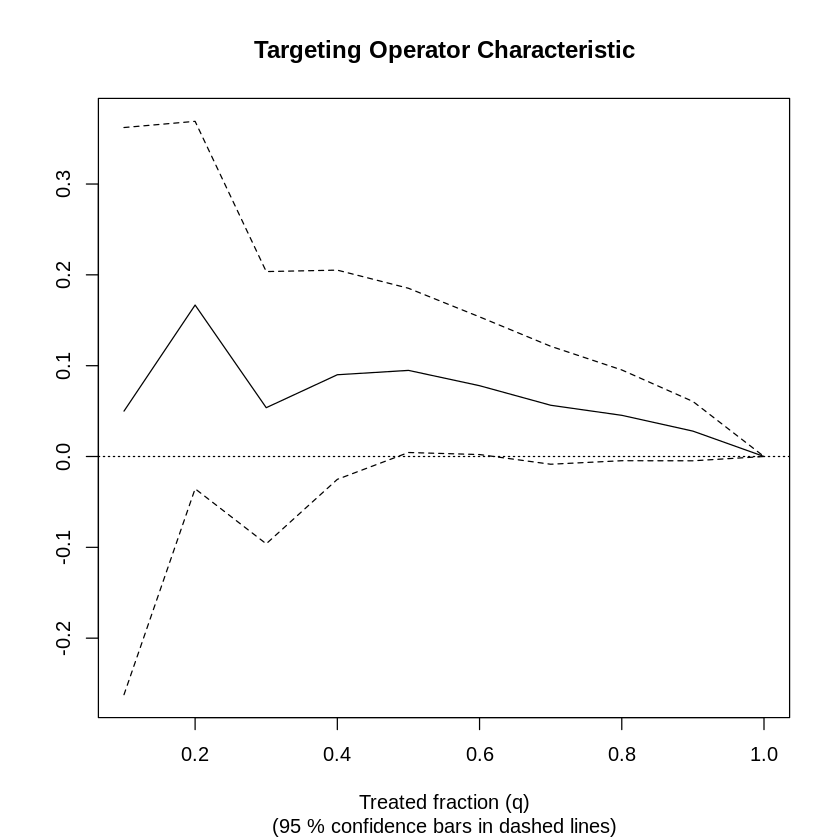

In [2]:
library(grf)

# Generate data.
n <- 2000
p <- 10
X <- matrix(rnorm(n * p), n, p)
X.test <- matrix(0, 101, p)
X.test[, 1] <- seq(-2, 2, length.out = 101)

# Train a causal forest.
W <- rbinom(n, 1, 0.4 + 0.2 * (X[, 1] > 0))
Y <- pmax(X[, 1], 0) * W + X[, 2] + pmin(X[, 3], 0) + rnorm(n)
tau.forest <- causal_forest(X, Y, W)

# Estimate treatment effects for the training data using out-of-bag prediction.
tau.hat.oob <- predict(tau.forest)
hist(tau.hat.oob$predictions)

# Estimate treatment effects for the test sample.
tau.hat <- predict(tau.forest, X.test)
plot(X.test[, 1], tau.hat$predictions, ylim = range(tau.hat$predictions, 0, 2), xlab = "x", ylab = "tau", type = "l")
lines(X.test[, 1], pmax(0, X.test[, 1]), col = 2, lty = 2)

# Estimate the conditional average treatment effect on the full sample (CATE).
average_treatment_effect(tau.forest, target.sample = "all")

# Estimate the conditional average treatment effect on the treated sample (CATT).
average_treatment_effect(tau.forest, target.sample = "treated")

# Add confidence intervals for heterogeneous treatment effects; growing more trees is now recommended.
tau.forest <- causal_forest(X, Y, W, num.trees = 4000)
tau.hat <- predict(tau.forest, X.test, estimate.variance = TRUE)
sigma.hat <- sqrt(tau.hat$variance.estimates)
plot(X.test[, 1], tau.hat$predictions, ylim = range(tau.hat$predictions + 1.96 * sigma.hat, tau.hat$predictions - 1.96 * sigma.hat, 0, 2), xlab = "x", ylab = "tau", type = "l")
lines(X.test[, 1], tau.hat$predictions + 1.96 * sigma.hat, col = 1, lty = 2)
lines(X.test[, 1], tau.hat$predictions - 1.96 * sigma.hat, col = 1, lty = 2)
lines(X.test[, 1], pmax(0, X.test[, 1]), col = 2, lty = 1)

# In some examples, pre-fitting models for Y and W separately may
# be helpful (e.g., if different models use different covariates).
# In some applications, one may even want to get Y.hat and W.hat
# using a completely different method (e.g., boosting).

# Generate new data.
n <- 4000
p <- 20
X <- matrix(rnorm(n * p), n, p)
TAU <- 1 / (1 + exp(-X[, 3]))
W <- rbinom(n, 1, 1 / (1 + exp(-X[, 1] - X[, 2])))
Y <- pmax(X[, 2] + X[, 3], 0) + rowMeans(X[, 4:6]) / 2 + W * TAU + rnorm(n)

forest.W <- regression_forest(X, W, tune.parameters = "all")
W.hat <- predict(forest.W)$predictions

forest.Y <- regression_forest(X, Y, tune.parameters = "all")
Y.hat <- predict(forest.Y)$predictions

forest.Y.varimp <- variable_importance(forest.Y)

# Note: Forests may have a hard time when trained on very few variables
# (e.g., ncol(X) = 1, 2, or 3). We recommend not being too aggressive
# in selection.
selected.vars <- which(forest.Y.varimp / mean(forest.Y.varimp) > 0.2)

tau.forest <- causal_forest(X[, selected.vars], Y, W,
                            W.hat = W.hat, Y.hat = Y.hat,
                            tune.parameters = "all")

# See if a causal forest succeeded in capturing heterogeneity by plotting
# the TOC and calculating a 95% CI for the AUTOC.
train <- sample(1:n, n / 2)
train.forest <- causal_forest(X[train, ], Y[train], W[train])
eval.forest <- causal_forest(X[-train, ], Y[-train], W[-train])
rate <- rank_average_treatment_effect(eval.forest,
                                      predict(train.forest, X[-train, ])$predictions)
plot(rate)
paste("AUTOC:", round(rate$estimate, 2), "+/", round(1.96 * rate$std.err, 2))